## Data prep:

##### Process Listing

1. Loading the Data
2. dealing with data in the wrong format 
3. dealing with missing values
4. Data Transformation
5. check the correlation between values
6. Save the data for post processing

In [ ]:
data

collection
understanding
cleaning
transformation
    log transformation
    label encoding
feature enginering
integration nill
splittingformatting
validataion


### Loading the data

In [54]:
import pandas as pd

In [55]:
main_data = pd.read_csv(r"source_data/INDUSTRY_COPPER.csv")
main_data.head()

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33
3,F8D507A0-9C62-4EFE-831E-33E1DA53BB50,20210401.0,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,DX51D+ZM310MAO 2.3X1317,1668701718,20210101.0,768.00
4,4E1C4E78-152B-430A-8094-ADD889C9D0AD,20210401.0,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,2_S275JR+AR-CL1,640665,20210301.0,577.00


In [56]:
# check for how many orignal data in the pd.DataFrame
main_data.shape

(181673, 14)

## dealing with data in the wrong format 

In [57]:
# handling data and time
main_data['item_date'] = pd.to_datetime(main_data['item_date'], format='%Y%m%d', errors='coerce').dt.date

In [58]:
# handling the catogtical variable
main_data['quantity tons'] = pd.to_numeric(main_data['quantity tons'], errors='coerce')
main_data['customer'] = pd.to_numeric(main_data['customer'], errors='coerce')
main_data['country'] = pd.to_numeric(main_data['country'], errors='coerce')
main_data['application'] = pd.to_numeric(main_data['application'], errors='coerce')
main_data['thickness'] = pd.to_numeric(main_data['thickness'], errors='coerce')
main_data['width'] = pd.to_numeric(main_data['width'], errors='coerce')
main_data['material_ref'] = main_data['material_ref'].str.lstrip('0')
main_data['product_ref'] = pd.to_numeric(main_data['product_ref'], errors='coerce')
main_data['delivery date'] = pd.to_datetime(main_data['delivery date'], format='%Y%m%d', errors='coerce').dt.date
main_data['selling_price'] = pd.to_numeric(main_data['selling_price'], errors='coerce')

## dealing with missing values

In [59]:
# check for number of missing values
main_data.isnull().sum()

id                   2
item_date            3
quantity tons        1
customer             1
country             28
status               2
item type            0
application         24
thickness            1
width                0
material_ref     77919
product_ref          0
delivery date        3
selling_price        1
dtype: int64

In [60]:
# material_ref - 77919 is 42.89% of the whole data. can't be droped instead replaceing it with 'None'  
main_data['material_ref'].fillna('none', inplace=True)

In [61]:
# remove all the Null values in this DataFrame
main_data.dropna(inplace=True)

In [62]:
# Check again for the missing values.
main_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

## Data Transformation

In [63]:
plot_data = main_data.copy()

In [64]:
# plot the data in an distplot for identifing skewed data

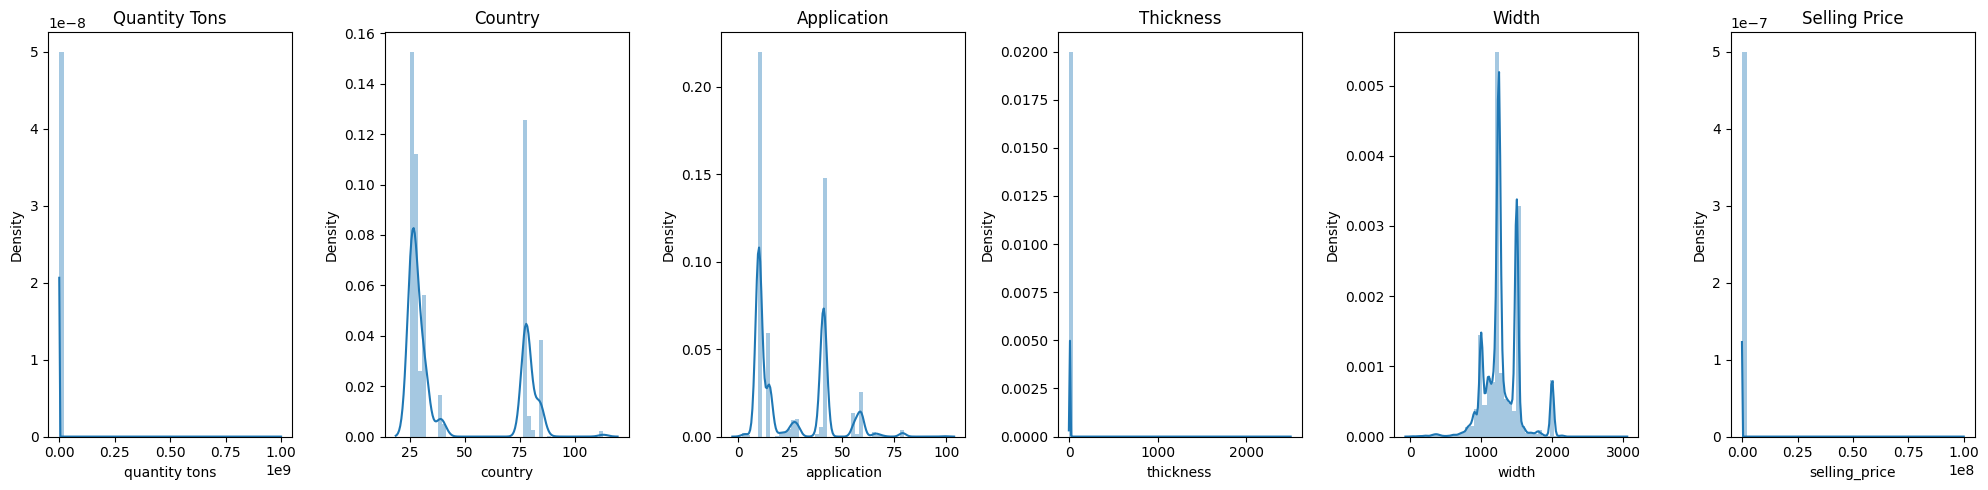

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Create a figure with 1 row and 6 columns
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot each distribution in a separate subplot
sns.distplot(plot_data['quantity tons'], ax=axes[0])
axes[0].set_title('Quantity Tons')

sns.distplot(plot_data['country'], ax=axes[1])
axes[1].set_title('Country')

sns.distplot(plot_data['application'], ax=axes[2])
axes[2].set_title('Application')

sns.distplot(plot_data['thickness'], ax=axes[3])
axes[3].set_title('Thickness')

sns.distplot(plot_data['width'], ax=axes[4])
axes[4].set_title('Width')

sns.distplot(plot_data['selling_price'], ax=axes[5])
axes[5].set_title('Selling Price')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [66]:
# "Quantity_tons", "thickness" and "selling price" all three is skewed

In [67]:
# Normalize all three of the data by replacing with nan
import numpy as np

mask1 = plot_data['selling_price'] <= 0
print(f"selling_price => {mask1.sum()}")
plot_data.loc[mask1, 'selling_price'] = np.nan

mask1 = plot_data['quantity tons'] <= 0
print(f"quantity tons => {mask1.sum()}")
plot_data.loc[mask1, 'quantity tons'] = np.nan

mask1 = plot_data['thickness'] <= 0
print(f"thickness => {mask1.sum()}")
plot_data.loc[mask1, 'thickness'] = np.nan

selling_price => 7
quantity tons => 4
thickness => 0


In [68]:
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    4
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    7
dtype: int64

In [69]:
plot_data.dropna(inplace=True)
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

#### log transformation

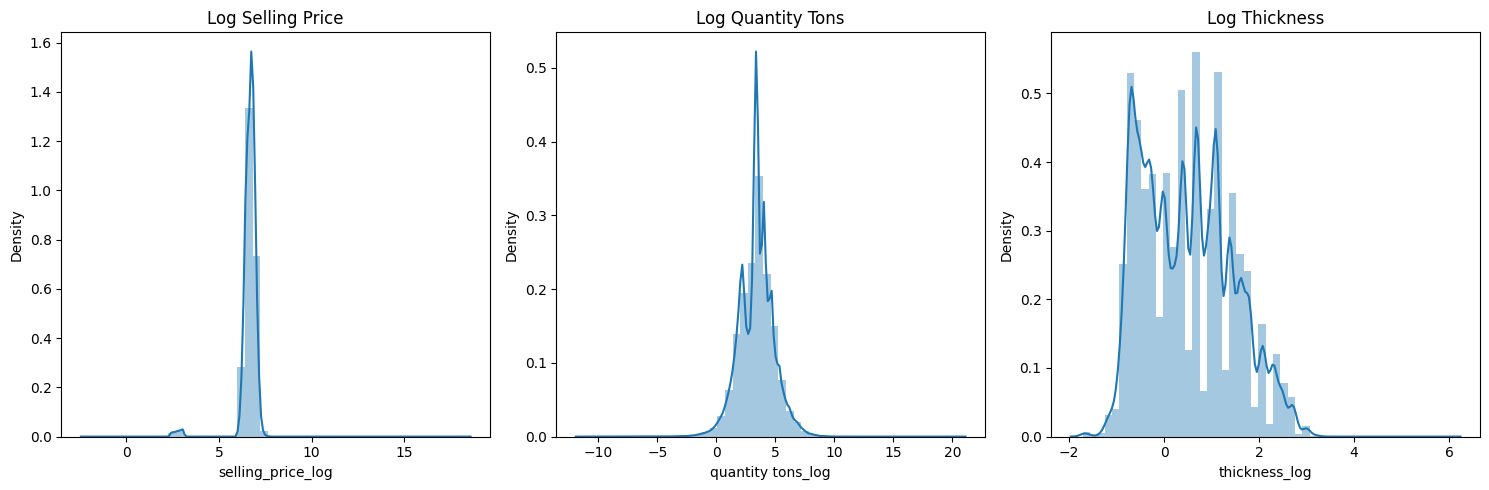

In [70]:
plot_data['selling_price_log'] = np.log(plot_data['selling_price'])
plot_data['quantity tons_log'] = np.log(plot_data['quantity tons'])
plot_data['thickness_log'] = np.log(plot_data['thickness'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.distplot(plot_data['selling_price_log'], ax=axes[0])
axes[0].set_title('Log Selling Price')

sns.distplot(plot_data['quantity tons_log'], ax=axes[1])
axes[1].set_title('Log Quantity Tons')

sns.distplot(plot_data['thickness_log'], ax=axes[2])
axes[2].set_title('Log Thickness')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## check the correlation between values in the data

In [71]:
x=plot_data[['quantity tons_log','application','thickness_log',
             'width','selling_price_log','country','customer','product_ref']].corr()

<Axes: >

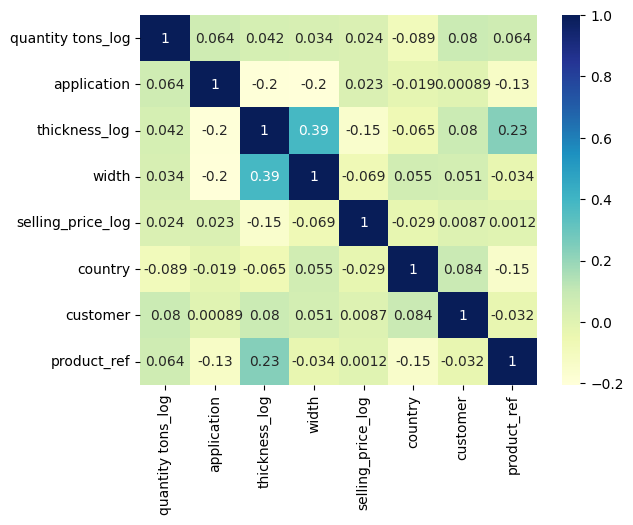

In [72]:
sns.heatmap(x, annot=True, cmap="YlGnBu")

## Load the data to a file

In [73]:
# for training and other works

In [74]:
plot_data.to_csv('source_data/preprocessed_data.csv', index=False)